## Question 1: Intensity Transformations

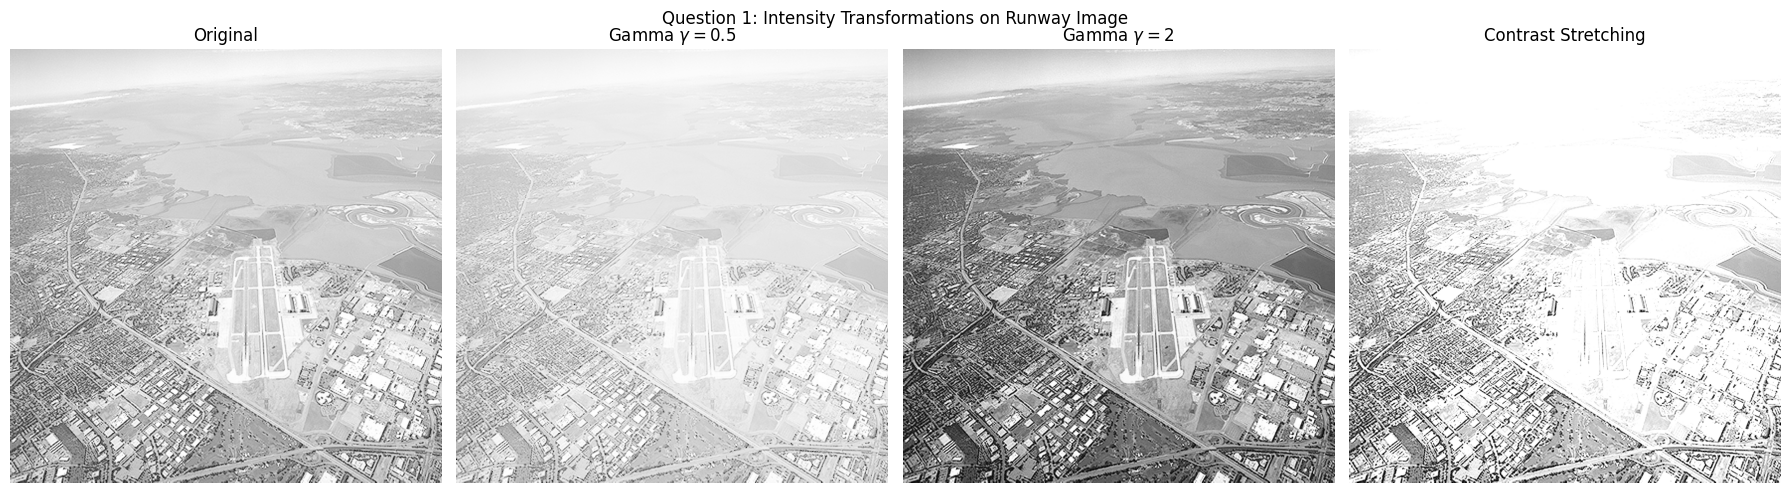

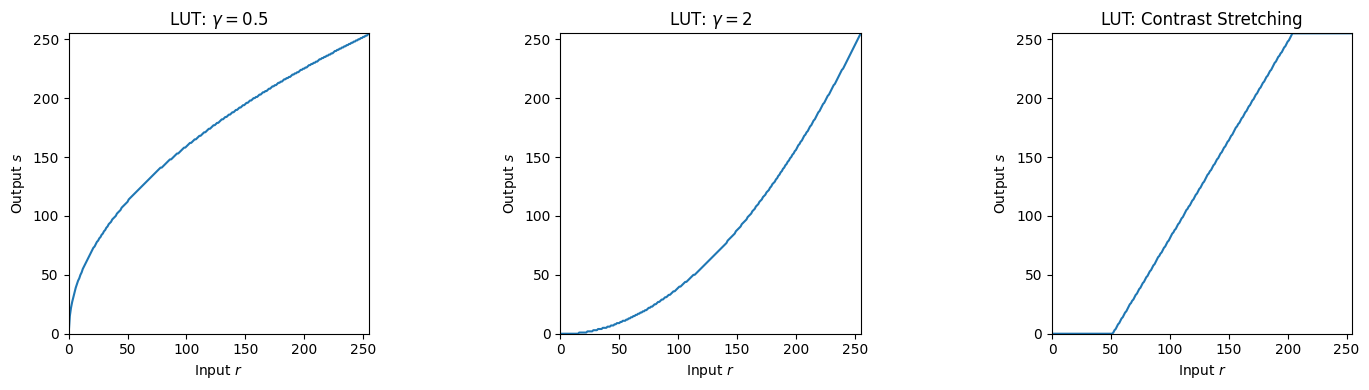

In [1]:
# Question 1: Intensity Transformations
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the runway image
img = cv.imread('E:/ML/Images/Fig0309(a)(washed_out_aerial_image).tif', cv.IMREAD_GRAYSCALE)
assert img is not None, 'Could not load runway image'

#(a) Gamma correction γ = 0.5 
gamma_05 = 0.5
table_05 = np.array([(i / 255.0) ** gamma_05 * 255.0
                     for i in np.arange(0, 256)]).astype('uint8')
img_gamma_05 = cv.LUT(img, table_05)

#(b) Gamma correction γ = 2 
gamma_2 = 2
table_2 = np.array([(i / 255.0) ** gamma_2 * 255.0
                    for i in np.arange(0, 256)]).astype('uint8')
img_gamma_2 = cv.LUT(img, table_2)

#(c) Contrast Stretching 
r1, r2 = 0.2, 0.8
contrast_table = np.zeros(256, dtype='uint8')
for i in range(256):
    r = i / 255.0
    if r < r1:
        s = 0.0
    elif r <= r2:
        s = (r - r1) / (r2 - r1)
    else:
        s = 1.0
    contrast_table[i] = np.clip(s * 255, 0, 255)

img_contrast = cv.LUT(img, contrast_table)

# Display all results
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titles = ['Original', r'Gamma $\gamma=0.5$', r'Gamma $\gamma=2$', 'Contrast Stretching']
images = [img, img_gamma_05, img_gamma_2, img_contrast]

for ax, title, image in zip(axes, titles, images):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Question 1: Intensity Transformations on Runway Image')
plt.tight_layout()
plt.savefig('q1_intensity_transforms.png', dpi=150)
plt.show()

# Plot the transform functions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(table_05)
axes[0].set_title(r'LUT: $\gamma = 0.5$')
axes[1].plot(table_2)
axes[1].set_title(r'LUT: $\gamma = 2$')
axes[2].plot(contrast_table)
axes[2].set_title('LUT: Contrast Stretching')
for ax in axes:
    ax.set_xlabel(r'Input $r$')
    ax.set_ylabel(r'Output $s$')
    ax.set_xlim(0, 255)
    ax.set_ylim(0, 255)
    ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('q1_lut_curves.png', dpi=150)
plt.show()